# Results analysis

Plots and comparisons for the four models.

Run this from the project root (`thesis_project/`) so the relative
`results/...` paths resolve.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import glob, os
from pathlib import Path
plt.rcParams['figure.dpi'] = 110


PROJECT_ROOT = Path.cwd().parent
RESULTS = PROJECT_ROOT / "results"


## 1. Final model comparison (test set)

In [6]:
test_files = {
    "baseline": f"{RESULTS}/baseline_64f_112px_clipp1_pretrained_test.csv",
    "cnn_lstm": f"{RESULTS}/cnn_lstm_64f_112px_clipp1_pretrained_test.csv",
    "r3d":      f"{RESULTS}/r3d_64f_112px_clipp1_pretrained_test.csv",
    "swin3d":   f"{RESULTS}/swin3d_32f_224px_clipp2_pretrained_test.csv",
}

rows = []
for name, path in test_files.items():
    df = pd.read_csv(path)
    r = df.iloc[0]
    rows.append({
        "model": name,
        "test_auc": r["test_auc"],
        "test_acc": r["test_acc"],
        "test_f1": r["test_f1"],
        "epochs": r["num_epochs"],
    })

summary = pd.DataFrame(rows).sort_values("test_auc", ascending=False).reset_index(drop=True)
summary


,model,test_auc,test_acc,test_f1,epochs
0,r3d,0.934232,0.873923,0.917138,12
1,swin3d,0.912359,0.869225,0.916207,15
2,baseline,0.908355,0.825372,0.879394,15
3,cnn_lstm,0.899844,0.860611,0.915076,15


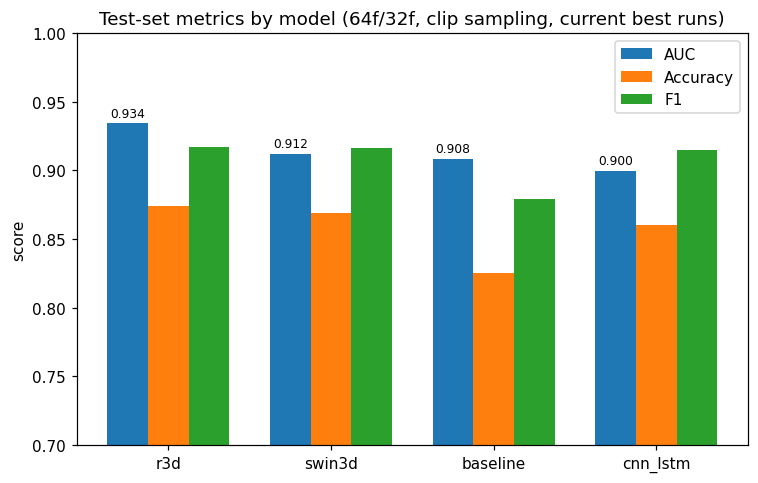

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(summary))
width = 0.25

ax.bar(x - width, summary["test_auc"], width, label="AUC")
ax.bar(x,          summary["test_acc"], width, label="Accuracy")
ax.bar(x + width,  summary["test_f1"],  width, label="F1")

ax.set_xticks(x)
ax.set_xticklabels(summary["model"])
ax.set_ylim(0.7, 1.0)
ax.set_ylabel("score")
ax.set_title("Test-set metrics by model (64f/32f, clip sampling, current best runs)")
ax.legend()
for i, v in enumerate(summary["test_auc"]):
    ax.text(i - width, v + 0.005, f"{v:.3f}", ha="center", fontsize=8)
fig.tight_layout()
plt.show()


## 2. R3D: the learning-rate-split mistake and the fix

Initial R3D run used the Swin3D backbone/head LR split (1e-5 / 1e-4, 15 epochs). This was unnecessary for R3D and caused the head to overfit while the backbone updated too slowly.

Broken run: metrics copied from`slurm-r3d-35372135.out` (superseded run).
Fixed run: no LR split, 12 epochs, loaded from `results/r3d_64f_112px_clipp1_pretrained_history.csv`.

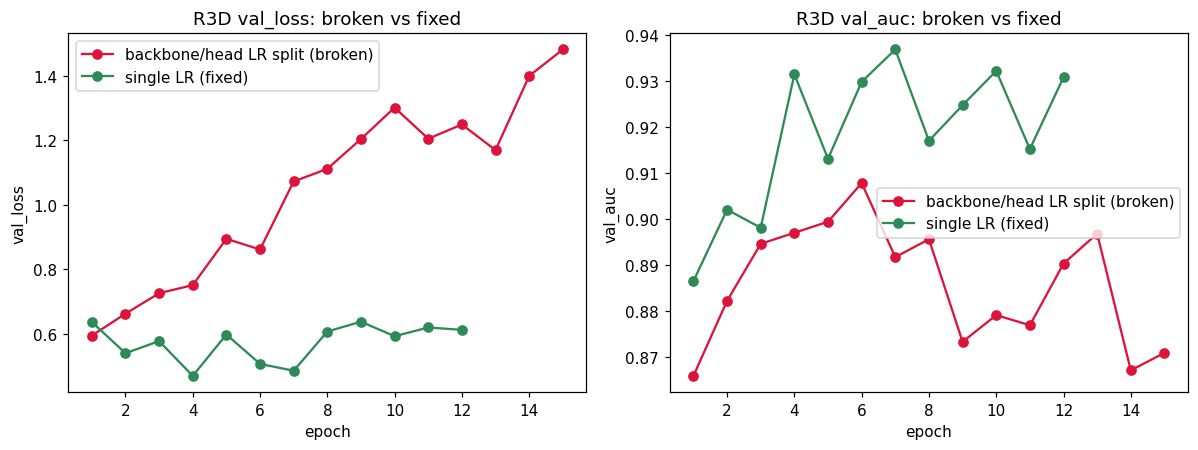

broken run  - best val_auc: 0.9079 (epoch 6), final val_loss: 1.482
fixed run   - best val_auc: 0.9369 (epoch 7), final val_loss: 0.612


In [ ]:
broken_r3d = pd.DataFrame({
    "epoch":     list(range(1, 16)),
    "val_loss":  [0.5938,0.6618,0.7255,0.7505,0.8943,0.8611,1.0722,1.1114,1.2039,1.3014,1.2048,1.2490,1.1695,1.3997,1.4817],
    "val_auc":   [0.8660,0.8823,0.8947,0.8971,0.8995,0.9079,0.8918,0.8957,0.8734,0.8792,0.8770,0.8904,0.8969,0.8672,0.8710],
    "train_loss":[0.7265,0.6598,0.5887,0.5428,0.4412,0.3940,0.2924,0.2308,0.2201,0.1545,0.1586,0.1497,0.1196,0.1141,0.0982],
})

fixed_r3d = pd.read_csv(f"{RESULTS}/r3d_64f_112px_clipp1_pretrained_history.csv")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].plot(broken_r3d["epoch"], broken_r3d["val_loss"], "o-", color="crimson", label="backbone/head LR split (broken)")
axes[0].plot(fixed_r3d["epoch"], fixed_r3d["val_loss"], "o-", color="seagreen", label="single LR (fixed)")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("val_loss")
axes[0].set_title("R3D val_loss: broken vs fixed")
axes[0].legend()

axes[1].plot(broken_r3d["epoch"], broken_r3d["val_auc"], "o-", color="crimson", label="backbone/head LR split (broken)")
axes[1].plot(fixed_r3d["epoch"], fixed_r3d["val_auc"], "o-", color="seagreen", label="single LR (fixed)")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("val_auc")
axes[1].set_title("R3D val_auc: broken vs fixed")
axes[1].legend()

fig.tight_layout()
plt.show()

print(f"broken run  - best val_auc: {broken_r3d['val_auc'].max():.4f} (epoch {broken_r3d['val_auc'].idxmax()+1}), final val_loss: {broken_r3d['val_loss'].iloc[-1]:.3f}")
print(f"fixed run   - best val_auc: {fixed_r3d['val_auc'].max():.4f} (epoch {fixed_r3d['val_auc'].idxmax()+1}), final val_loss: {fixed_r3d['val_loss'].iloc[-1]:.3f}")


## 3. Swin3D: the collapse and the fix

The very first Swin3D run (`results/history/swin3d_t_32f_224px_pretrained_history.csv`)
never learned anything. val_acc/val_f1 identical every epoch, val_auc stuck
near chance. Fixed with staged backbone freezing, a backbone/head LR split
(the split that hurt R3D is exactly what this model needed), warmup + cosine
decay, and gradient clipping, see `results/swin3d_32f_224px_clipp2_pretrained_history.csv`.

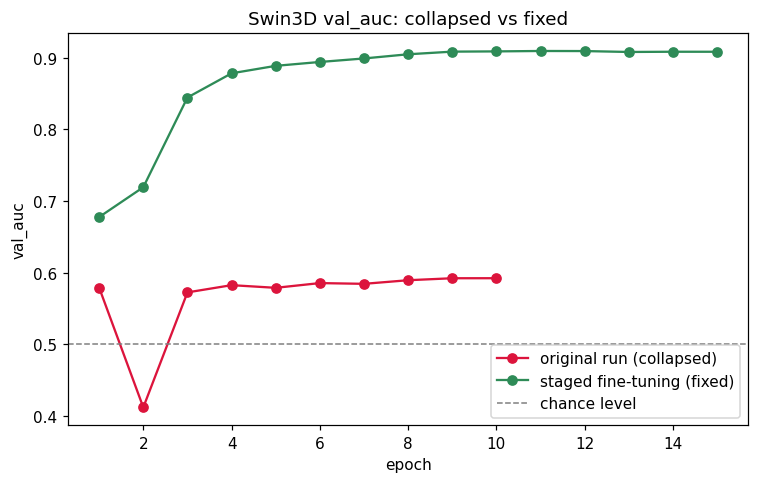

collapsed run - val_auc range: 0.412 - 0.592
fixed run     - val_auc range: 0.678 - 0.909


In [9]:
collapsed_swin = pd.read_csv(f"{RESULTS}/history/swin3d_t_32f_224px_pretrained_history.csv")
fixed_swin = pd.read_csv(f"{RESULTS}/swin3d_32f_224px_clipp2_pretrained_history.csv")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(collapsed_swin["epoch"], collapsed_swin["val_auc"], "o-", color="crimson", label="original run (collapsed)")
ax.plot(fixed_swin["epoch"], fixed_swin["val_auc"], "o-", color="seagreen", label="staged fine-tuning (fixed)")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="chance level")
ax.set_xlabel("epoch"); ax.set_ylabel("val_auc")
ax.set_title("Swin3D val_auc: collapsed vs fixed")
ax.legend()
fig.tight_layout()
plt.show()

print(f"collapsed run - val_auc range: {collapsed_swin['val_auc'].min():.3f} - {collapsed_swin['val_auc'].max():.3f}")
print(f"fixed run     - val_auc range: {fixed_swin['val_auc'].min():.3f} - {fixed_swin['val_auc'].max():.3f}")


## 4. Near-EF-50 boundary cases: R3D vs Swin3D

Both models were run through the interpretability script on the same 8 test
videos, deliberately chosen within 5 EF points of the 50 threshold (the
hardest cases). Transcribed from `slurm-interp-35374808.out` (R3D) and
`slurm-interp-35374919.out` (Swin3D).

In [10]:
boundary = pd.DataFrame([
    {"video": "0X6BA7CB2E44532208", "ef": 54.7, "true": 1, "r3d_correct": True,  "swin3d_correct": True},
    {"video": "0X608ED3201BB2F9A",  "ef": 53.0, "true": 1, "r3d_correct": True,  "swin3d_correct": True},
    {"video": "0X1D393AED88F9D056", "ef": 45.3, "true": 0, "r3d_correct": True,  "swin3d_correct": False},
    {"video": "0X4A0C7C0FE8253F6E", "ef": 52.8, "true": 1, "r3d_correct": True,  "swin3d_correct": True},
    {"video": "0X73CBCADA2191104C", "ef": 49.5, "true": 0, "r3d_correct": False, "swin3d_correct": True},
    {"video": "0X86643606EDB99E8",  "ef": 53.3, "true": 1, "r3d_correct": True,  "swin3d_correct": True},
    {"video": "0X45357AC4B9F02268", "ef": 45.4, "true": 0, "r3d_correct": True,  "swin3d_correct": True},
    {"video": "0X3B80677CE0873E50", "ef": 49.8, "true": 0, "r3d_correct": False, "swin3d_correct": False},
])

print(f"R3D:    {boundary['r3d_correct'].sum()}/8 correct")
print(f"Swin3D: {boundary['swin3d_correct'].sum()}/8 correct")
print()
print("Cases only R3D got right:   ", list(boundary[boundary.r3d_correct & ~boundary.swin3d_correct]["video"]))
print("Cases only Swin3D got right:", list(boundary[boundary.swin3d_correct & ~boundary.r3d_correct]["video"]))
print("Cases BOTH got wrong:       ", list(boundary[~boundary.r3d_correct & ~boundary.swin3d_correct]["video"]))

boundary


R3D:    6/8 correct
Swin3D: 6/8 correct

Cases only R3D got right:    ['0X1D393AED88F9D056']
Cases only Swin3D got right: ['0X73CBCADA2191104C']
Cases BOTH got wrong:        ['0X3B80677CE0873E50']


,video,ef,true,r3d_correct,swin3d_correct
0,0X6BA7CB2E44532208,54.7,1,True,True
1,0X608ED3201BB2F9A,53.0,1,True,True
2,0X1D393AED88F9D056,45.3,0,True,False
3,0X4A0C7C0FE8253F6E,52.8,1,True,True
4,0X73CBCADA2191104C,49.5,0,False,True
5,0X86643606EDB99E8,53.3,1,True,True
6,0X45357AC4B9F02268,45.4,0,True,True
7,0X3B80677CE0873E50,49.8,0,False,False


## 5. Interpretability overlays

Grad-CAM (R3D) and occlusion sensitivity (Swin3D) on a couple of the
near-boundary examples above - one where both models were right, and the one
case both got wrong.

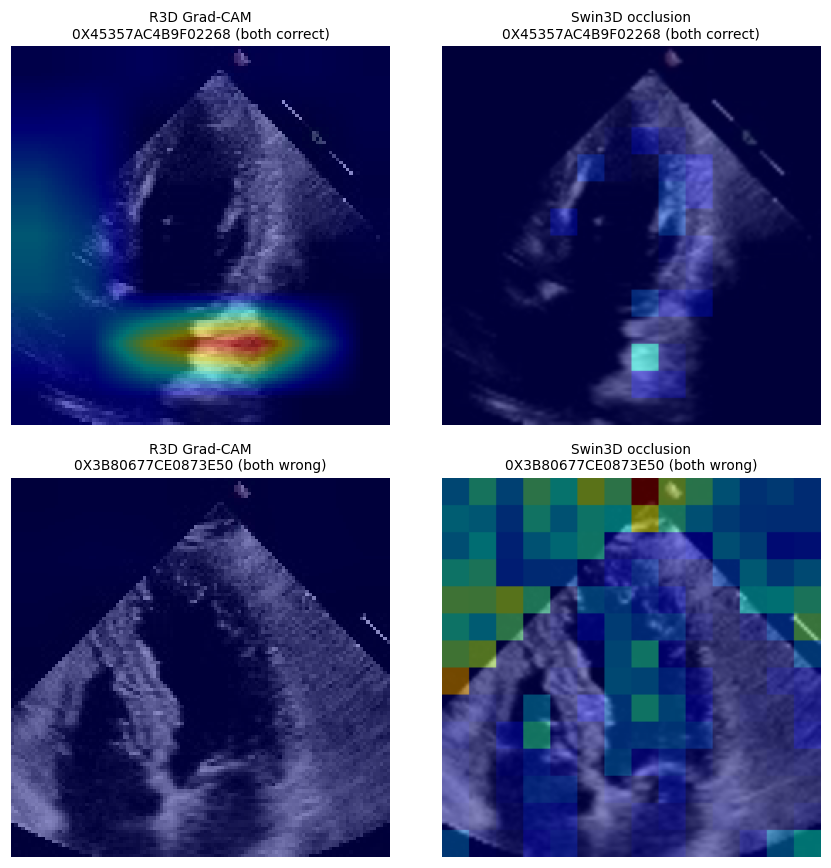

In [11]:
def show_frame(ax, path, title):
    if os.path.exists(path):
        img = Image.open(path)
        ax.imshow(img)
    ax.set_title(title, fontsize=9)
    ax.axis("off")

examples = [
    ("0X45357AC4B9F02268", "EF45", "label0", "both correct"),
    ("0X3B80677CE0873E50", "EF50", "label0", "both wrong"),
]

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
for row, (vid, ef, label, tag) in enumerate(examples):
    r3d_path = f"{RESULTS}/interpretability/r3d_{vid}_{ef}_{label}/frame_027.png"
    swin_path = glob.glob(f"{RESULTS}/interpretability/swin3d_{vid}_{ef}_{label}/frame_0*.png")
    swin_path = sorted(swin_path)[3] if swin_path else None

    show_frame(axes[row][0], r3d_path, f"R3D Grad-CAM\n{vid} ({tag})")
    if swin_path:
        show_frame(axes[row][1], swin_path, f"Swin3D occlusion\n{vid} ({tag})")
    else:
        axes[row][1].axis("off")

fig.tight_layout()
plt.show()


## Takeaways

- R3D is the best model right now (test AUC 0.934), Swin3D close behind
  (0.912) now that its collapse is fixed, both clearly ahead of the
  baseline (0.908) and CNN+LSTM (0.900), though the gap between all four is
  smaller than I expected going in.
- The R3D and Swin3D fixes were opposite prescriptions for opposite
  problems: Swin3D needed its backbone protected with a much smaller LR and
  a warmup because it was collapsing; R3D needed the *opposite* (one LR for
  the whole network) because it was already learning fine and the split
  just made it overfit faster. 
- On the hardest cases (near the EF=50 boundary), R3D and Swin3D disagree on
  which ones they get right more often than I expected, only one video
  fooled both models. That complementary error pattern is a reasonable nudge
  towards an ensemble as future work, even if there isn't time to build one
  now.
- Both models' Grad-CAM/occlusion overlays concentrate around the central
  chamber region rather than scattering across the frame, which is a
  reasonable sanity check that they're not keying off scan artifacts.